In [11]:
import zipfile
import os

zip_path = '/content/archive.zip'
extract_path = '.'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Extracted to {os.path.abspath(extract_path)}")

Extracted to /content


In [12]:
data_dir = '/content/processed_data'


In [13]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Define transformations
data_transforms = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load dataset
full_dataset = datasets.ImageFolder(root=data_dir, transform=None)

# Split sizes
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

print(f"Train size: {len(train_dataset)}")
print(f"Val size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")

Train size: 34845
Val size: 7466
Test size: 7468


In [14]:
import shutil
from tqdm import tqdm

def create_split_dirs(base_path, dataset, split_name):
    """Copies images from a Subset to a physical directory structure."""
    for i in tqdm(range(len(dataset)), desc=f"Creating {split_name} set"):
        # Get original path and label
        path, label_idx = dataset.dataset.samples[dataset.indices[i]]
        class_name = dataset.dataset.classes[label_idx]

        # Define destination
        target_dir = os.path.join(base_path, split_name, class_name)
        os.makedirs(target_dir, exist_ok=True)

        # Copy file
        shutil.copy(path, os.path.join(target_dir, os.path.basename(path)))

# Define the root directory for the split data
output_root = '/content/final_dataset'

# Execute copying for each split
create_split_dirs(output_root, train_dataset, 'train')
create_split_dirs(output_root, val_dataset, 'val')
create_split_dirs(output_root, test_dataset, 'test')

print(f"\nDataset successfully organized in: {os.path.abspath(output_root)}")

Creating test set: 100%|██████████| 7468/7468 [00:00<00:00, 10782.01it/s]


Dataset successfully organized in: /content/final_dataset


In [15]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchmetrics import Accuracy
import multiprocessing


In [16]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [17]:
# get directories
train_dir = '/content/final_dataset/train'
val_dir = '/content/final_dataset/val'
test_dir = '/content/final_dataset/test'

In [18]:
# Apply transforms if needed (standard for models)
stats = ((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])


In [19]:
train_data = datasets.ImageFolder(train_dir, transform=train_transform)
val_data = datasets.ImageFolder(val_dir, transform=test_transform)
test_data = datasets.ImageFolder(test_dir, transform=test_transform)

# Dictionary of labels
class_names = train_data.classes
class_to_idx = train_data.class_to_idx
print(f'Classes: {class_names}')

# DataLoaders
BATCH_SIZE = 32
NUM_WORKERS = 2

train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_dataloader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [20]:
try:
    from torchinfo import summary
except:
    %pip install torchinfo
    from torchinfo import summary

# 5. Create TinyVGG architecture adjusted for 224x224 inputs
class TinyVGG(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(input_shape, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.MaxPool2d(kernel_size=2)
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.MaxPool2d(kernel_size=2)
        )
        self.block_3 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.MaxPool2d(kernel_size=2)
        )
        # For 224x224 input, after three MaxPool2d(2), size is 224 -> 112 -> 56 -> 28
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_units * 28 * 28, output_shape)
        )

    def forward(self, x):
        return self.classifier(self.block_3(self.block_2(self.block_1(x))))

In [21]:
model_vgg = TinyVGG(3, 16, len(class_names)).to(device)

# 6. Print Summary
summary(model_vgg, input_size=[1, 3, 224, 224])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 7]                    --
├─Sequential: 1-1                        [1, 16, 112, 112]         --
│    └─Conv2d: 2-1                       [1, 16, 224, 224]         448
│    └─ReLU: 2-2                         [1, 16, 224, 224]         --
│    └─Conv2d: 2-3                       [1, 16, 224, 224]         2,320
│    └─ReLU: 2-4                         [1, 16, 224, 224]         --
│    └─Dropout: 2-5                      [1, 16, 224, 224]         --
│    └─MaxPool2d: 2-6                    [1, 16, 112, 112]         --
├─Sequential: 1-2                        [1, 16, 56, 56]           --
│    └─Conv2d: 2-7                       [1, 16, 112, 112]         2,320
│    └─ReLU: 2-8                         [1, 16, 112, 112]         --
│    └─Conv2d: 2-9                       [1, 16, 112, 112]         2,320
│    └─ReLU: 2-10                        [1, 16, 112, 112]         --
│    

In [22]:
try:
    from ignite.engine import Events, create_supervised_trainer, create_supervised_evaluator
    from ignite.metrics import Loss, Accuracy as IgniteAccuracy
    from ignite.handlers import EarlyStopping
except:
    %pip install pytorch-ignite
    from ignite.engine import Events, create_supervised_trainer, create_supervised_evaluator
    from ignite.metrics import Loss, Accuracy as IgniteAccuracy
    from ignite.handlers import EarlyStopping
from tqdm.auto import tqdm
import torch


In [23]:
def train_step(model, dataloader, loss_fn, optimizer, accuracy_fn, device, position=None):
    model.train()
    train_loss, train_acc = 0, 0
    accuracy_fn.reset()
    for X, y in tqdm(dataloader, desc="Training", leave=False, position=position):
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        accuracy_fn.update(y_pred.argmax(dim=1), y)
    train_acc = accuracy_fn.compute().item()
    return train_loss / len(dataloader), train_acc

In [24]:
def test_step(model, dataloader, loss_fn, accuracy_fn, device, position=None):
    model.eval()
    test_loss, test_acc = 0, 0
    accuracy_fn.reset()
    with torch.inference_mode():
        for X, y in tqdm(dataloader, desc="Testing", leave=False, position=position):
            X, y = X.to(device), y.to(device)
            test_pred = model(X)
            test_loss += loss_fn(test_pred, y).item()
            accuracy_fn.update(test_pred.argmax(dim=1), y)
    test_acc = accuracy_fn.compute().item()
    return test_loss / len(dataloader), test_acc

In [25]:
def train_loop(model, train_dataloader, test_dataloader, optimizer, loss_fn, accuracy_fn, epochs, device, patience=3):
    results = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    best_test_loss = float("inf")

    # Setup Ignite objects for EarlyStopping
    trainer = create_supervised_trainer(model, optimizer, loss_fn, device=device)
    evaluator = create_supervised_evaluator(model, metrics={"accuracy": IgniteAccuracy(), "loss": Loss(loss_fn)}, device=device)

    def score_function(engine):
        return -engine.state.metrics["loss"]

    handler = EarlyStopping(patience=patience, score_function=score_function, trainer=trainer)
    evaluator.add_event_handler(Events.COMPLETED, handler)

    for epoch in tqdm(range(epochs), desc="Epochs", position=0, leave=True):
        train_loss, train_acc = train_step(model, train_dataloader, loss_fn, optimizer, accuracy_fn, device, position=1)
        test_loss, test_acc = test_step(model, test_dataloader, loss_fn, accuracy_fn, device, position=1)

        print(f"Epoch: {epoch+1} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

        # Save Checkpoint
        if test_loss < best_test_loss:
            best_test_loss = test_loss
            torch.save(model.state_dict(), "best_model_checkpoint.pth")
            print(f"Checkpoint saved: New best test loss {best_test_loss:.4f}")

        # Use Ignite evaluator to check for early stopping trigger
        evaluator.run(test_dataloader)
        if trainer.should_terminate:
            print("Early stopping triggered.")
            break

    return results

In [26]:
%pip install torchmetrics

In [27]:
import torchmetrics
# 9. Instantiate and Train TinyVGG
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_vgg.parameters(), lr=0.001)
acc_fn = torchmetrics.Accuracy(task='multiclass', num_classes=7).to(device)

In [28]:
vgg_results = train_loop(model_vgg, train_dataloader, val_dataloader, optimizer, loss_fn, acc_fn, epochs=10, device=device)


Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Training:   0%|          | 0/1089 [00:00<?, ?it/s]

Testing:   0%|          | 0/234 [00:00<?, ?it/s]

Epoch: 1 | Train Loss: 1.4878 | Train Acc: 0.4246 | Test Loss: 1.3314 | Test Acc: 0.5009
Checkpoint saved: New best test loss 1.3314


Training:   0%|          | 0/1089 [00:00<?, ?it/s]

...

Training:   0%|          | 0/1089 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x791122ada7a0><function _MultiProcessingDataLoaderIter.__del__ at 0x791122ada7a0>

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
        self._shutdown_workers()
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x791122ada7a0>self._shutdown_workers()  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers


Traceback (most recent call last):
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
if w.is_alive():  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    
if w.is

Testing:   0%|          | 0/234 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x791122ada7a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    Exception ignored in: self._shutdown_workers()<function _MultiProcessingDataLoaderIter.__del__ at 0x791122ada7a0>
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers

Traceback (most recent call last):
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    if w.is_alive():self._shutdown_workers()

   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
         if w.is_alive():
  ^ ^^ ^^   ^ ^^^^^^^^^^^
^Exception ignored in:   File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^<function _MultiProcessingDataLoaderIter.__del__ at 0x791122ada7a0>^assert sel

Epoch: 10 | Train Loss: 0.9306 | Train Acc: 0.6527 | Test Loss: 1.1210 | Test Acc: 0.5757


In [29]:
# Load the best model configuration and weights
model_vgg.load_state_dict(torch.load('best_model_checkpoint.pth'))
model_vgg.to(device)
model_vgg.eval()

print("Successfully loaded the best model configuration from 'best_model_checkpoint.pth'")

# Quick evaluation check on validation data
val_loss, val_acc = test_step(model_vgg, val_dataloader, loss_fn, acc_fn, device)
print(f"Best Model Validation Loss: {val_loss:.4f}")
print(f"Best Model Validation Accuracy: {val_acc:.4f}")

Successfully loaded the best model configuration from 'best_model_checkpoint.pth'


Testing:   0%|          | 0/234 [00:00<?, ?it/s]

Best Model Validation Loss: 1.1199
Best Model Validation Accuracy: 0.5735


In [30]:
import matplotlib.pyplot as plt

def plot_metrics(num_epochs, train_loss, train_accuracy, test_loss, test_accuracy):
  # Get the number of epochs from the length of one of the result lists
  epochs = range(num_epochs)

  # Convert GPU tensors to CPU and then to Python floats for plotting
  plot_train_loss = [loss.cpu().item() if isinstance(loss, torch.Tensor) else loss for loss in train_loss]
  plot_test_loss = [loss.cpu().item() if isinstance(loss, torch.Tensor) else loss for loss in test_loss]
  plot_train_accuracy = [acc.cpu().item() if isinstance(acc, torch.Tensor) else acc for acc in train_accuracy]
  plot_test_accuracy = [acc.cpu().item() if isinstance(acc, torch.Tensor) else acc for acc in test_accuracy]

  plt.figure(figsize=(15, 7))

  # Plot loss
  plt.subplot(1, 2, 1)
  plt.plot(epochs, plot_train_loss, label='Train Loss')
  plt.plot(epochs, plot_test_loss, label='Test Loss')
  plt.title('Training and Test Loss Over Epochs')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()
  plt.grid(True)

  # Plot Accuracy
  plt.subplot(1, 2, 2)
  plt.plot(epochs, plot_train_accuracy, label='Train Accuracy')
  plt.plot(epochs, plot_test_accuracy, label='Test Accuracy')
  plt.title('Training and Test Accuracy Over Epochs')
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.legend()
  plt.grid(True)

  plt.tight_layout()
  plt.show()

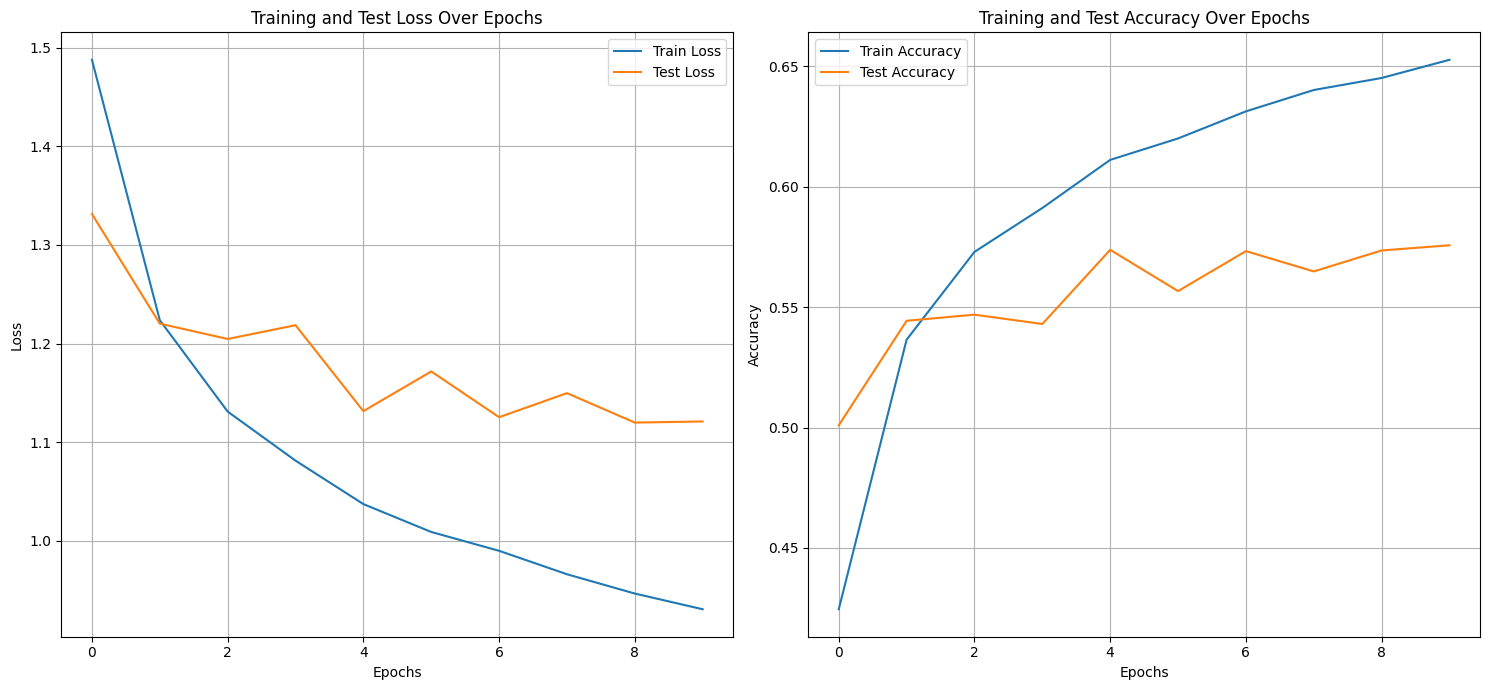

In [31]:
num_epochs = len(vgg_results['train_loss'])
plot_metrics(
    num_epochs=num_epochs,
    train_loss=vgg_results['train_loss'],
    train_accuracy=vgg_results['train_acc'],
    test_loss=vgg_results['test_loss'],
    test_accuracy=vgg_results['test_acc']
)

In [32]:
# 11. ResNet50
model_resnet = models.resnet50(weights='DEFAULT')
num_ftrs = model_resnet.fc.in_features
model_resnet.fc = nn.Linear(num_ftrs, len(class_names))
model_resnet = model_resnet.to(device)

optimizer_res = torch.optim.Adam(model_resnet.parameters(), lr=0.001)
resnet_results = train_loop(model_resnet, train_dataloader, val_dataloader, optimizer_res, loss_fn, acc_fn, epochs=10, device=device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 162MB/s]


Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Training:   0%|          | 0/1089 [00:00<?, ?it/s]

Testing:   0%|          | 0/234 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x791122ada7a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x791122ada7a0>
^Traceback (most recent call last):
^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
        assert self._parent_pid == os.getpid(), 'can only test a child process'self._shutdown_workers()

   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
      if w.is_alive():  
          ^  ^ ^^^^^^^^^^^^^^^^^^^^^^^

Testing:   0%|          | 0/234 [00:00<?, ?it/s]

Epoch: 9 | Train Loss: 0.3609 | Train Acc: 0.8705 | Test Loss: 0.8894 | Test Acc: 0.7120


2026-05-01 09:52:19,829 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training


Early stopping triggered.


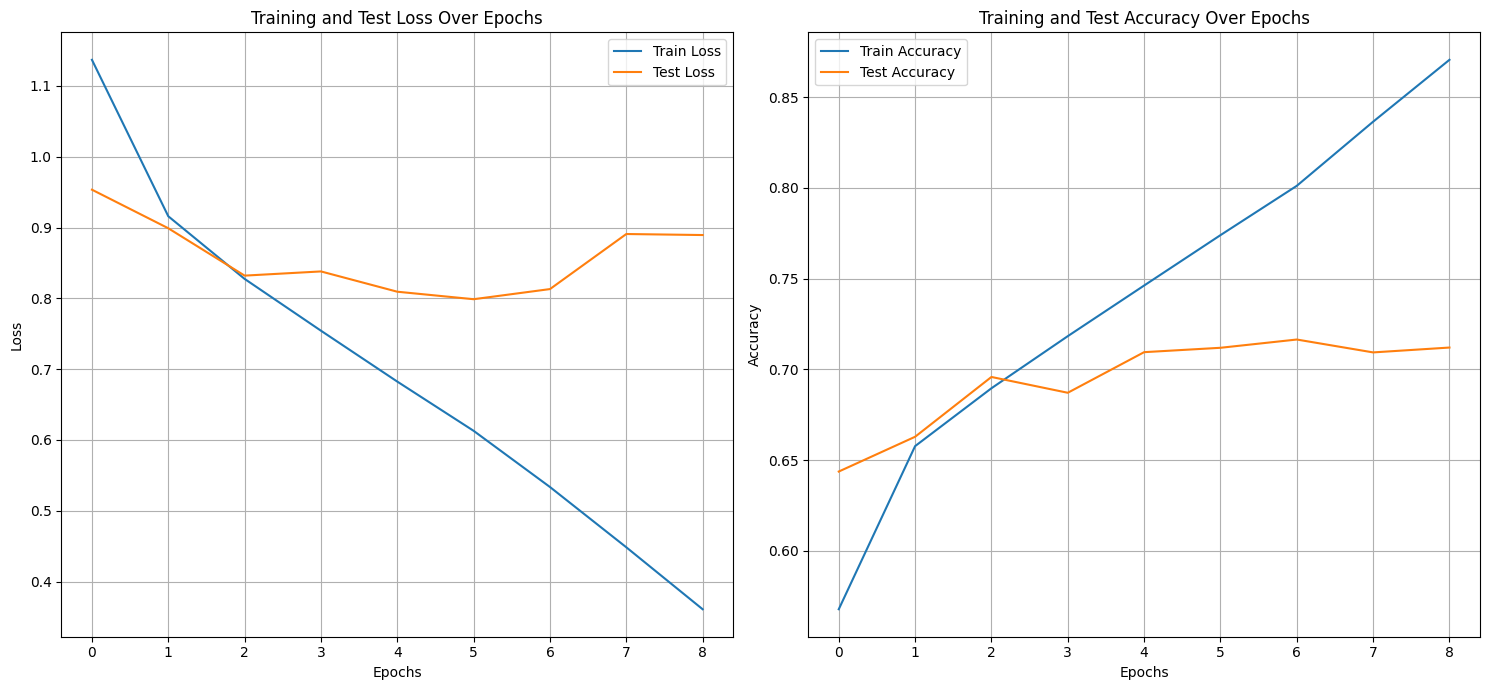

In [33]:
# 12. Plot ResNet results
num_epochs = len(resnet_results['train_loss'])
plot_metrics(
    num_epochs=num_epochs,
    train_loss=resnet_results['train_loss'],
    train_accuracy=resnet_results['train_acc'],
    test_loss=resnet_results['test_loss'],
    test_accuracy=resnet_results['test_acc']
)

In [34]:
# Load the best model state dictionary saved during training
model_resnet.load_state_dict(torch.load('best_model_checkpoint.pth'))
model_resnet.to(device)
model_resnet.eval()

print('Successfully loaded the best model weights from best_model_checkpoint.pth')

# Quick evaluation check on validation data
val_loss, val_acc = test_step(model_resnet, val_dataloader, loss_fn, acc_fn, device)
print(f"Best Model Validation Loss: {val_loss:.4f}")
print(f"Best Model Validation Accuracy: {val_acc:.4f}")


Successfully loaded the best model weights from best_model_checkpoint.pth


Testing:   0%|          | 0/234 [00:00<?, ?it/s]

Best Model Validation Loss: 0.7987
Best Model Validation Accuracy: 0.7119


### Strategy: Fine-Tuning ResNet50 and Learning Rate Scheduling
We will unfreeze the last few layers of the ResNet50 model and introduce a learning rate scheduler to improve convergence.

In [35]:
model_resnet_finetune = models.resnet50(weights='DEFAULT')
num_ftrs = model_resnet_finetune.fc.in_features
model_resnet_finetune.fc = nn.Linear(num_ftrs, len(class_names))
model_resnet_finetune = model_resnet_finetune.to(device)

# Unfreeze Layer 4, and FC for better performance
for name, param in model_resnet_finetune.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

optimizer_ft = torch.optim.AdamW(filter(lambda p: p.requires_grad, model_resnet_finetune.parameters()), lr=1e-4, weight_decay=1e-2)

# Using OneCycleLR for faster and more stable convergence
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer_ft, max_lr=1e-3,
                                                steps_per_epoch=len(train_dataloader),
                                                epochs=10)

print("ResNet50 prepared with unshared layer3, layer4 and AdamW optimizer.")

ResNet50 prepared with unshared layer3, layer4 and AdamW optimizer.


In [36]:
resnet_fine_tuned_results = train_loop(model_resnet, train_dataloader, val_dataloader, optimizer_res, loss_fn, acc_fn, epochs=10, device=device)


Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Training:   0%|          | 0/1089 [00:00<?, ?it/s]

Testing:   0%|          | 0/234 [00:00<?, ?it/s]

Epoch: 1 | Train Loss: 0.5246 | Train Acc: 0.8064 | Test Loss: 0.7994 | Test Acc: 0.7197
Checkpoint saved: New best test loss 0.7994


Training:   0%|          | 0/1089 [00:00<?, ?it/s]

...

Training:   0%|          | 0/1089 [00:00<?, ?it/s]

Testing:   0%|          | 0/234 [00:00<?, ?it/s]

Epoch: 4 | Train Loss: 0.2895 | Train Acc: 0.8977 | Test Loss: 0.9226 | Test Acc: 0.7154


2026-05-01 10:20:11,800 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training


Early stopping triggered.


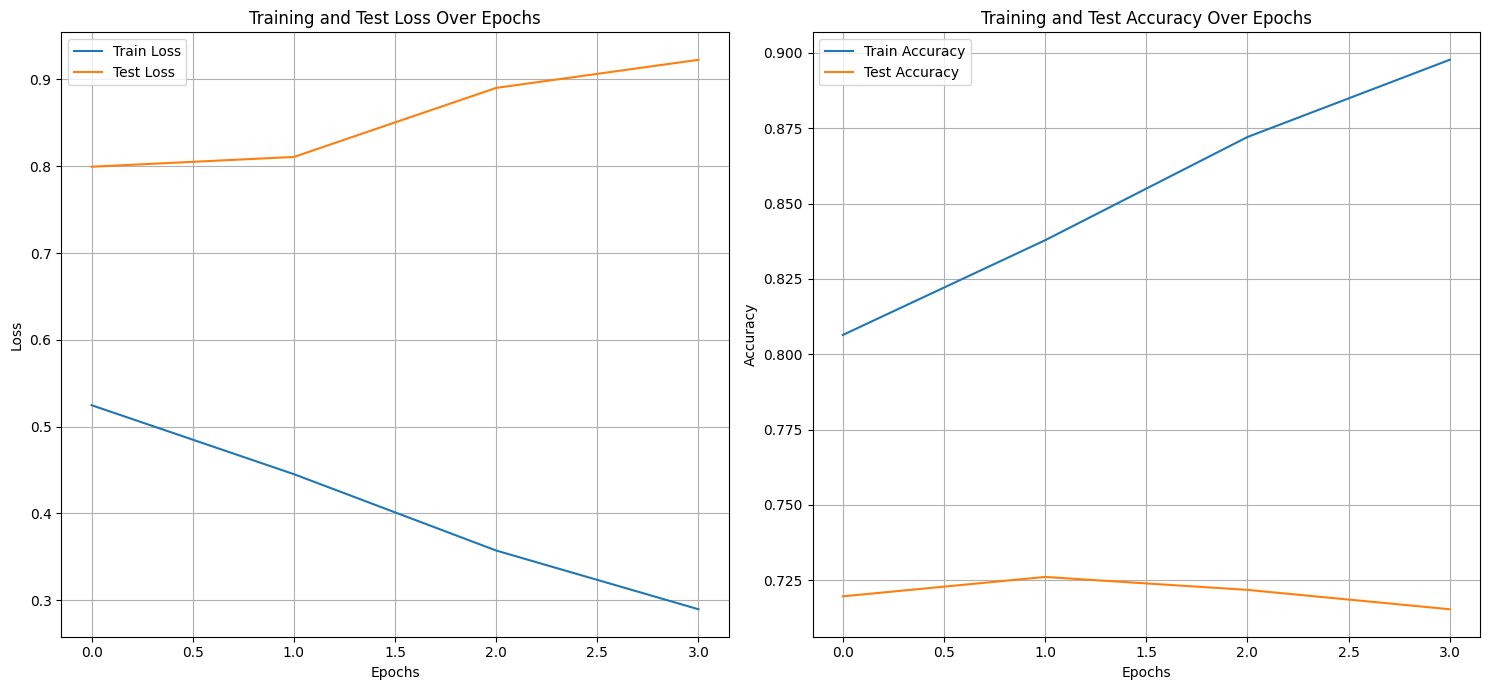

In [37]:
# 12. Plot ResNet results
num_epochs = len(resnet_fine_tuned_results['train_loss'])
plot_metrics(
    num_epochs=num_epochs,
    train_loss=resnet_fine_tuned_results['train_loss'],
    train_accuracy=resnet_fine_tuned_results['train_acc'],
    test_loss=resnet_fine_tuned_results['test_loss'],
    test_accuracy=resnet_fine_tuned_results['test_acc']
)

### Ensemble Learning: ResNet50 Features + Random Forest
In this section, we use the ResNet50 model as a feature extractor (removing the final classification layer) and train a Scikit-Learn Random Forest on the resulting embeddings.

In [38]:
%pip install scikit-learn

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

def get_features(model, dataloader, device):
    model.eval()
    features = []
    labels = []

    # Remove the final FC layer to get embeddings
    feature_extractor = torch.nn.Sequential(*list(model.children())[:-1])

    with torch.inference_mode():
        for X, y in tqdm(dataloader, desc="Extracting Features"):
            X = X.to(device)
            # Output shape is [batch, 2048, 1, 1] for ResNet50
            emb = feature_extractor(X)
            emb = emb.view(emb.size(0), -1) # Flatten to [batch, 2048]
            features.append(emb.cpu().numpy())
            labels.append(y.numpy())

    return np.concatenate(features), np.concatenate(labels)

print("Extracting features from train and validation sets...")
X_train_features, y_train = get_features(model_resnet_finetune, train_dataloader, device)
X_val_features, y_val = get_features(model_resnet_finetune, val_dataloader, device)

Extracting features from train and validation sets...


Extracting Features:   0%|          | 0/1089 [00:00<?, ?it/s]

Extracting Features:   0%|          | 0/234 [00:00<?, ?it/s]

In [40]:
# Initialize and train Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf_clf.fit(X_train_features, y_train)

# Predictions
y_pred = rf_clf.predict(X_val_features)
print(f"Random Forest Ensemble Accuracy: {accuracy_score(y_val, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=class_names))

Random Forest Ensemble Accuracy: 0.4720

Classification Report:
              precision    recall  f1-score   support

       angry       0.32      0.17      0.22       871
     disgust       0.62      0.70      0.66       876
        fear       0.37      0.23      0.28       953
       happy       0.51      0.81      0.63      1701
     neutral       0.42      0.50      0.46      1196
         sad       0.36      0.24      0.29       968
    surprise       0.50      0.36      0.42       901

    accuracy                           0.47      7466
   macro avg       0.44      0.43      0.42      7466
weighted avg       0.45      0.47      0.44      7466



In [44]:
import joblib
from PIL import Image
import matplotlib.pyplot as plt

def predict_custom_image(image_path, model, rf_model=None, class_names=class_names, transform=test_transform, device=device):
    # Ensure image exists and is loaded
    img = Image.open(image_path).convert('RGB')
    transformed_image = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.inference_mode():
        # 1. Get CNN Prediction
        logits = model(transformed_image)
        cnn_probs = torch.softmax(logits, dim=1)
        cnn_label = torch.argmax(cnn_probs, dim=1).item()

        # 2. Get Random Forest Prediction if provided
        rf_label_name = "N/A"
        if rf_model is not None:
            # Extract features using the model as a feature extractor
            feature_extractor = torch.nn.Sequential(*list(model.children())[:-1])
            features = feature_extractor(transformed_image).view(1, -1).cpu().numpy()
            rf_pred = rf_model.predict(features)[0]
            rf_label_name = class_names[rf_pred]

    plt.figure(figsize=(6, 4))
    plt.imshow(img)
    plt.title(f"CNN: {class_names[cnn_label]} ({cnn_probs.max():.2f})\nRF: {rf_label_name}")
    plt.axis('off')
    plt.show()

--- TinyVGG Prediction ---


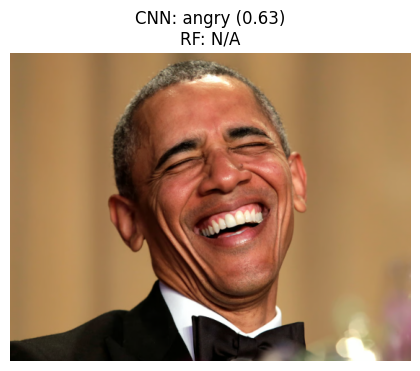

--- ResNet50 (Standard) Prediction ---


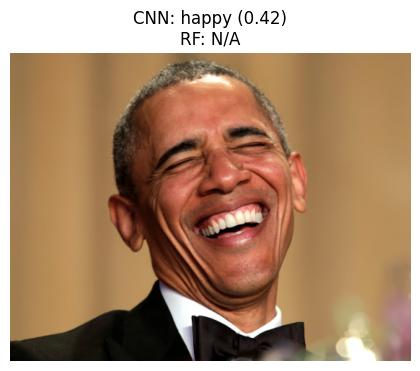

--- Fine-Tuned ResNet + Random Forest Prediction ---


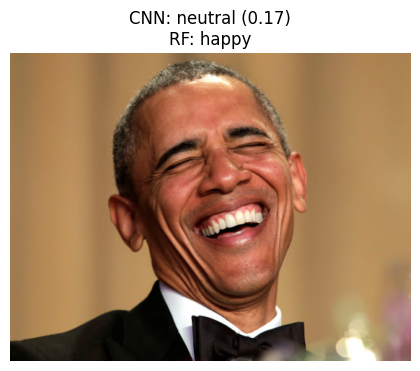

In [45]:
# Demonstration using the different models trained
image_path = "/content/Screenshot 2026-04-29 144806.png"

print("--- TinyVGG Prediction ---")
predict_custom_image(image_path, model=model_vgg)

print("--- ResNet50 (Standard) Prediction ---")
predict_custom_image(image_path, model=model_resnet)

print("--- Fine-Tuned ResNet + Random Forest Prediction ---")
# Pass the rf_clf to utilize the ensemble logic
predict_custom_image(image_path, model=model_resnet_finetune, rf_model=rf_clf)

In [47]:
import joblib

# Save the best PyTorch model state
torch.save(model_resnet_finetune.state_dict(), 'production_resnet_emotions.pth')

# Save the Random Forest model for production
joblib.dump(rf_clf, 'production_rf_classifier.pkl')

print("Production models saved: 'production_resnet_emotions.pth' and 'production_rf_classifier.pkl'")

Production models saved: 'production_resnet_emotions.pth' and 'production_rf_classifier.pkl'
